# 项目 2-1（★）从零手写感知机·胖瘦分类

- **练到**：权重更新规则、决策边界
- **数据**：自编数据，特征 `x1=身高(cm)`、`x2=体重(kg)`，归一化到 0~1，标签 0=偏瘦 1=偏胖（线性可分）。这正是笔记第 3 节"预测身材偏胖还是偏瘦"的案例。
- **任务**：仅用 numpy 手写感知机（不用 PyTorch），从权重全 0 开始迭代；把每次更新后的决策边界画在散点上，观察边界如何移动直至分开两类。
- **验收**：训练后训练准确率 100%；能打印出最终的 `w,b` 并画出直线 `w1*x1+w2*x2+b=0`。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [11]:
# ========== 1.准备数据（数据由豆包生成） ==========
data = np.loadtxt("2.1_data.csv", delimiter=',', skiprows=1, usecols=(0, 1))
label = np.loadtxt("2.1_data.csv", delimiter=',', skiprows=1, usecols=2).astype(int)
print('数据形状:', data.shape, label.shape)
print('前五行:\n', data[:5])
print('身高的范围(cm):', data[:, 0].min(), '~', data[:, 0].max())
print('体重的范围(kg):', data[:, 1].min(), '~', data[:, 1].max())
print(label[:5])

数据形状: (216, 2) (216,)
前五行:
 [[172.   58.2]
 [181.   84.7]
 [163.   51.4]
 [186.   91.3]
 [174.   60.1]]
身高的范围(cm): 154.0 ~ 194.0
体重的范围(kg): 41.0 ~ 103.8
[0 1 0 1 0]


In [20]:
# ========== 2.数据归一化 ==========
"""
因为身高和体重的值范围相差太大了，直接训练的话身高对权重的影响会远远大于体重，不合理。
"""
# 获取最大和最小值
X_min = data.min(axis=0)
X_max = data.max(axis=0)

# Min-Max 归一化
X = (data - X_min) / (X_max - X_min)
y = label # 为了与 X 对应，也可以不要

In [40]:
# ========== 3.定义感知机 ==========
class Perceptron:
    def __init__(self, lr=0.1, iterations=100):
        self.lr = lr                 # 学习率 η
        self.iterations = iterations # 最大迭代轮数
        self.w = None                # 权重 [w1, w2]
        self.b = None                # 偏置
        self.history = []            # 保存每轮 w, b，用来画决策边界变化

    def predict(self, x):
        # 计算加权和：z = w1·x1 + w2·x2 + b
        z = np.dot(self.w, x) + self.b
        return 1 if z >= 0 else 0

    def fit(self, X, y):
        _, n_features = X.shape

        # 权重、偏置全部初始化为 0
        self.w = np.zeros(n_features)
        self.b = 0.0

        for epoch in range(self.iterations):
            error_count = 0 # 本轮错误样本计数

            for xi, yi in zip(X, y):
                y_hat = self.predict(xi)

                # 如果预测错误，执行感知机更新规则
                if y_hat != yi:
                    e = yi - y_hat
                    self.w += self.lr * e * xi
                    self.b += self.lr * e
                    error_count += 1

            # 保存本轮参数
            self.history.append((self.w.copy(), self.b))

            # 打印进度
            print(f"epoch {epoch:2d} | error_count: {error_count} | w = {np.round(self.w, 4)}, b = {np.round(self.b, 4)}")

            # 全部样本预测正确，提前停止
            if error_count == 0:
                print(f"✅全部样本分类正确，提前结束训练，共迭代 {epoch+1} 轮")
                break

        return self

In [41]:
# ========== 4.开始训练 ==========
model = Perceptron(lr=0.01, iterations=100)
model.fit(X, y)

# 计算训练集准确率
correct = 0
for xi, yi in zip(X, y):
    if model.predict(xi) == yi:
        correct += 1

acc = correct / len(y)
print(f"训练集准确率：{acc:.2%}")
print(f"最终权重 [w1 w2] = {np.round(model.w, 4)}")
print(f"最终偏置 b = {np.round(model.b, 4)}")

epoch  0 | error_count: 7 | w = [0.0078 0.0131], b = -0.01
epoch  1 | error_count: 0 | w = [0.0078 0.0131], b = -0.01
✅全部样本分类正确，提前结束训练，共迭代 2 轮
训练集准确率：100.00%
最终权重 [w1 w2] = [0.0078 0.0131]
最终偏置 b = -0.01


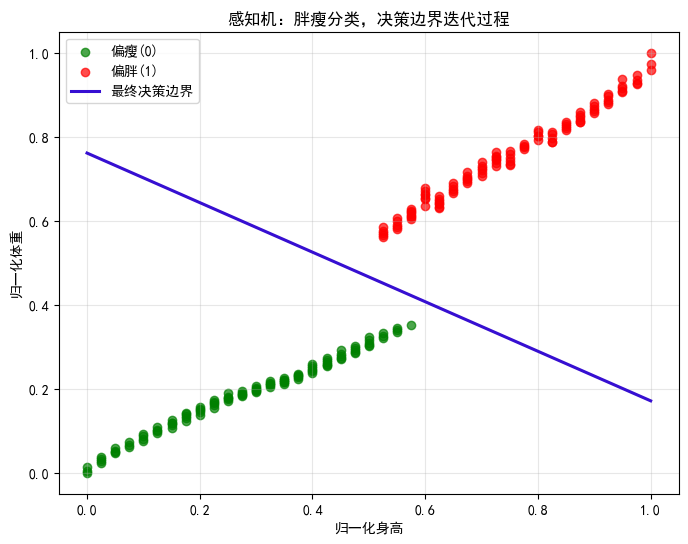

In [45]:
# ========== 5.绘制散点 + 多轮决策边界 ==========
"""
决策边界公式：w1 * x1 + w2 * x2 + b = 0
变形：x2 = (-w1 * x1 - b) / w2
"""
plt.figure(figsize=(8, 6))
# 绘制样本点
mask0 = (y == 0)
mask1 = (y == 1)
plt.scatter(X[mask0, 0], X[mask0, 1], c="green", label="偏瘦(0)", alpha=0.7)
plt.scatter(X[mask1, 0], X[mask1, 1], c="red", label="偏胖(1)", alpha=0.7)

# 画每一轮的决策边界
x1_line = np.linspace(0, 1, 100)
for idx, (wi, bi) in enumerate(model.history):
    w1, w2 = wi

    # 避免除零
    if abs(w2) < 1e-6:
        continue

    x2_line = (-w1 * x1_line - bi) / w2

    if idx != len(model.history) - 1:
        plt.plot(x1_line, x2_line, c="#ff8800", alpha=0.3)
    else:
        plt.plot(x1_line, x2_line, c="#360FD2", lw=2.2, label="最终决策边界")

plt.xlabel("归一化身高")
plt.ylabel("归一化体重")
plt.title("感知机：胖瘦分类，决策边界迭代过程")
plt.legend()
plt.grid(alpha=0.3)
plt.show()